In [2]:
!pip install plotly

In [3]:
!pip install anndata==0.8.0

In [4]:
!pip install -U kaleido

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time
import matplotlib.patches as mpatches


In [2]:
sm = load_samap('../../Subclustering/PVH/sm_hypoorgs_PVH_07242026.pkl')

In [3]:
sm.sams['cj'].adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'test', 'named_lc',
       'base_leiden_clusters', 'cluster_names', 'yw_clusters', 'eq_clusters',
       'eq_supertype', 'eq_supertype_v2', 'clusters_v2', 'eq_supertype_v

In [4]:
sm.sams['mg'].adata.obs['eq_supertype_v3'] = sm.sams['mg'].adata.obs['eq_supertype']

In [5]:
orgs = ['mg','mo','cj','ac','xt','dr']
pairs = [list(pair) for pair in itertools.combinations(orgs, 2)]
level = 'eq_supertype_v3'
for org_one, org_two in pairs:
    print(org_one, org_two)
    df_plt = pd.DataFrame(columns = ['celltype_org','celltype_ref','mapping','num_cells'])
    a = 0
    keys = {org_one:level,org_two:level}
    D,MappingTable = get_mapping_scores(sm,keys)

    lim_MappingTable = MappingTable.filter(like=org_one + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]
    lim_MappingTable.to_csv('../../Subclustering/PVH/Hypo/' + org_one + '_' + org_two + '_mapping_PVH_07262026_clusters.csv')

mg mo


/scratch/miniconda/lib/python3.7/site-packages/samap/analysis.py:1609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  samap.adata.obs[l] = pd.Categorical(cl)


mg cj
mg ac
mg xt
mg dr
mo cj
mo ac
mo xt
mo dr
cj ac
cj xt
cj dr
ac xt
ac dr
xt dr


In [6]:
#all dfs load
ct = 'PVH'
organisms = ['mg', 'mo', 'cj','ac','xt','dr']
level = 'eq_supertype_v3'

# Generate all unique pairs and read CSVs once
mapping = {}
for i, org1 in enumerate(organisms):
    for j, org2 in enumerate(organisms):
        key = f"{org1}_{org2}".upper()
        if i == j:
            uct = sm.sams[org1].adata.obs[level].unique()
            mapping[key] = pd.DataFrame(data = np.eye(len(uct)),index = [org1 + '_' + i for i in uct], columns = [org1 + '_' + i for i in uct])
        if i < j:
            # Read the file for this pair
            df = pd.read_csv(f'../../Subclustering/{ct}/Hypo/{org1}_{org2}_mapping_{ct}_07262026_clusters.csv', 
                             index_col='Unnamed: 0')
            mapping[key] = df
        else:
            # Derive from the transpose of the already-read file
            key = f"{org1}_{org2}".upper()
            reverse_key = f"{org2}_{org1}".upper()
            mapping[key] = mapping[reverse_key].T

In [7]:
organism_rows = {}
for org1 in organisms:
    dfs = [mapping[f"{org1}_{org2}".upper()] for org2 in organisms]
    organism_rows[org1.upper()] = pd.concat(dfs)

In [8]:
pvh_mapping = pd.concat([organism_rows[i.upper()] for i in organisms], axis = 1)

<AxesSubplot:>

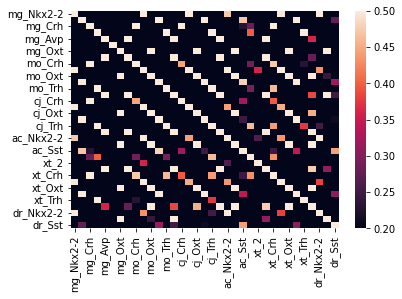

In [9]:
sns.heatmap(pvh_mapping, vmin = .2, vmax = .5)

In [10]:
pvh_mapping

,mg_Nkx2-2,mg_Sst,mg_Crh,mg_Trh,mg_Avp,mg_Ucn3,mg_Oxt,mo_Avp,mo_Crh,mo_Nkx2-2,...,xt_Avp,xt_Crh,xt_Nkx2-2,xt_Oxt,xt_Sst,xt_Trh,dr_Avp,dr_Nkx2-2,dr_Oxt,dr_Sst
mg_Nkx2-2,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002857,0.701254,...,0.000000,0.000000,0.498364,0.000113,0.000685,0.010734,0.042651,0.538318,0.042455,0.001918
mg_Sst,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000093,0.003379,0.005706,...,0.000046,0.011129,0.003921,0.010661,0.513853,0.005813,0.025110,0.003156,0.001788,0.276627
mg_Crh,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.001679,0.731970,0.001848,...,0.001616,0.503380,0.001451,0.000133,0.075147,0.052459,0.017064,0.046820,0.000008,0.094570
mg_Trh,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.031789,0.001788,...,0.000000,0.182228,0.000817,0.000739,0.007645,0.550868,0.040143,0.017242,0.008711,0.021356
mg_Avp,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.844499,0.008123,0.000317,...,0.801918,0.040554,0.005506,0.019876,0.000000,0.000000,0.360289,0.000490,0.065979,0.149446
mg_Ucn3,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.062162,...,0.000000,0.000134,0.077669,0.000034,0.016626,0.001871,0.001327,0.109175,0.001603,0.006318
mg_Oxt,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.178532,0.000000,0.005462,...,0.134046,0.000976,0.021567,0.911591,0.000000,0.000000,0.142326,0.010063,0.652517,0.005754
mo_Avp,0.000000,0.000093,0.001679,0.000000,0.844499,0.000000,0.178532,1.000000,0.000000,0.000000,...,0.742894,0.075278,0.000205,0.000000,0.000000,0.000000,0.278562,0.000048,0.022343,0.127838
mo_Crh,0.002857,0.003379,0.731970,0.031789,0.008123,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.006979,0.472868,0.004003,0.000000,0.014739,0.229865,0.032270,0.061035,0.000602,0.111492
mo_Nkx2-2,0.701254,0.005706,0.001848,0.001788,0.000317,0.062162,0.005462,0.000000,0.000000,1.000000,...,0.000000,0.000193,0.537646,0.000384,0.001059,0.014937,0.062512,0.433592,0.022953,0.016262


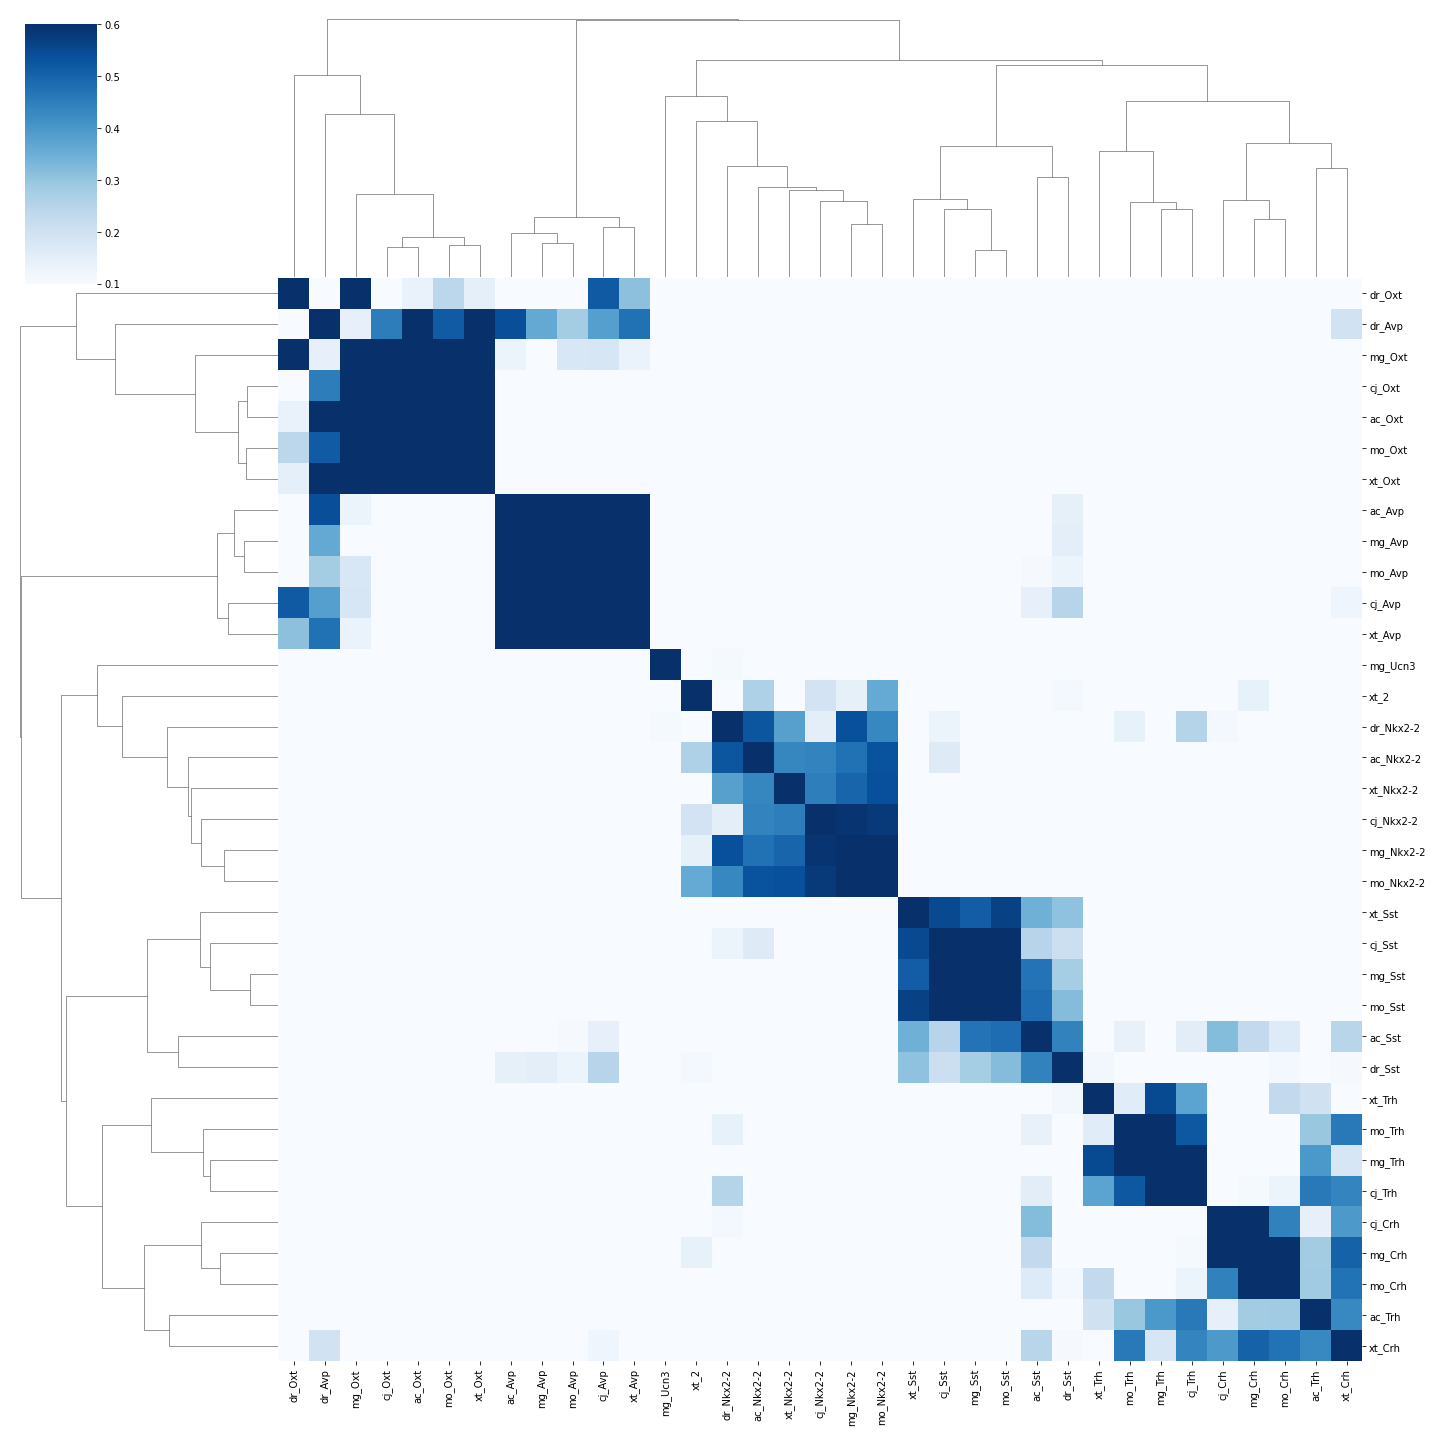

In [11]:
g =sns.clustermap(pvh_mapping, vmax = .6, vmin = .1,cmap = 'Blues',figsize=(20,20))

In [12]:
reorder_row = g.dendrogram_row.reordered_ind
reorder_col = g.dendrogram_col.reordered_ind

In [13]:
pvh_mapping_ord = pvh_mapping.loc[pvh_mapping.index[reorder_row],:]
pvh_mapping_ord = pvh_mapping_ord.loc[:,pvh_mapping.columns[reorder_col]]

In [14]:
pvh_mapping_ord.index

Index(['dr_Oxt', 'dr_Avp', 'mg_Oxt', 'cj_Oxt', 'ac_Oxt', 'mo_Oxt', 'xt_Oxt',
       'ac_Avp', 'mg_Avp', 'mo_Avp', 'cj_Avp', 'xt_Avp', 'mg_Ucn3', 'xt_2',
       'dr_Nkx2-2', 'ac_Nkx2-2', 'xt_Nkx2-2', 'cj_Nkx2-2', 'mg_Nkx2-2',
       'mo_Nkx2-2', 'xt_Sst', 'cj_Sst', 'mg_Sst', 'mo_Sst', 'ac_Sst', 'dr_Sst',
       'xt_Trh', 'mo_Trh', 'mg_Trh', 'cj_Trh', 'cj_Crh', 'mg_Crh', 'mo_Crh',
       'ac_Trh', 'xt_Crh'],
      dtype='object')

In [15]:
#Xt_2 is removed for plotting purposes
fmo = ['mg_Avp', 'mo_Avp','cj_Avp','ac_Avp','xt_Avp','dr_Avp', 
    'mg_Oxt', 'cj_Oxt', 'ac_Oxt', 'mo_Oxt', 'xt_Oxt','dr_Oxt',
    'mg_Nkx2-2','mo_Nkx2-2','cj_Nkx2-2','ac_Nkx2-2','xt_Nkx2-2','dr_Nkx2-2',    
        'mg_Ucn3', 
        'mg_Sst', 'mo_Sst','cj_Sst', 'ac_Sst', 'xt_Sst',  'dr_Sst',
        'mg_Crh', 'mo_Crh','cj_Crh', 'xt_Crh',
       'mg_Trh','mo_Trh','cj_Trh','ac_Trh', 'xt_Trh',]

In [16]:
#changed colors PVH
pvh_mapping_ord = pvh_mapping.loc[fmo,:]
pvh_mapping_ord = pvh_mapping_ord.loc[:,fmo]

category_one = [i[:2] for i in pvh_mapping_ord]
category_two = [i[3:] for i in pvh_mapping_ord]


color_map_one = {"mg": "#C9A185", "mo": "#C9A0DC", 'cj':'#ff7f0e',
                 'ac':'#9467bd',"xt": "#fa9189",
                'dr':'#bcbd22'}
color_map_two = {'Avp':'#4DAE49',
                   'Crh': '#F47E20',
                   'Nkx2-2':'#D3D3D3',
                   'Oxt':'#E11F26',
                   'Sst':'#ED82B4',
                   'Trh':'#974F9E',
                   'Ucn3':'#A65628',
                   'Nkx2-2':'#D3D3D3',
                   'unlabeled':'#D3D3D3'}

col_colors = pd.DataFrame({
    "Organism": pd.Series(category_one, index=pvh_mapping_ord.columns).map(color_map_one),
    "Celltype": pd.Series(category_two, index=pvh_mapping_ord.columns).map(color_map_two),
})

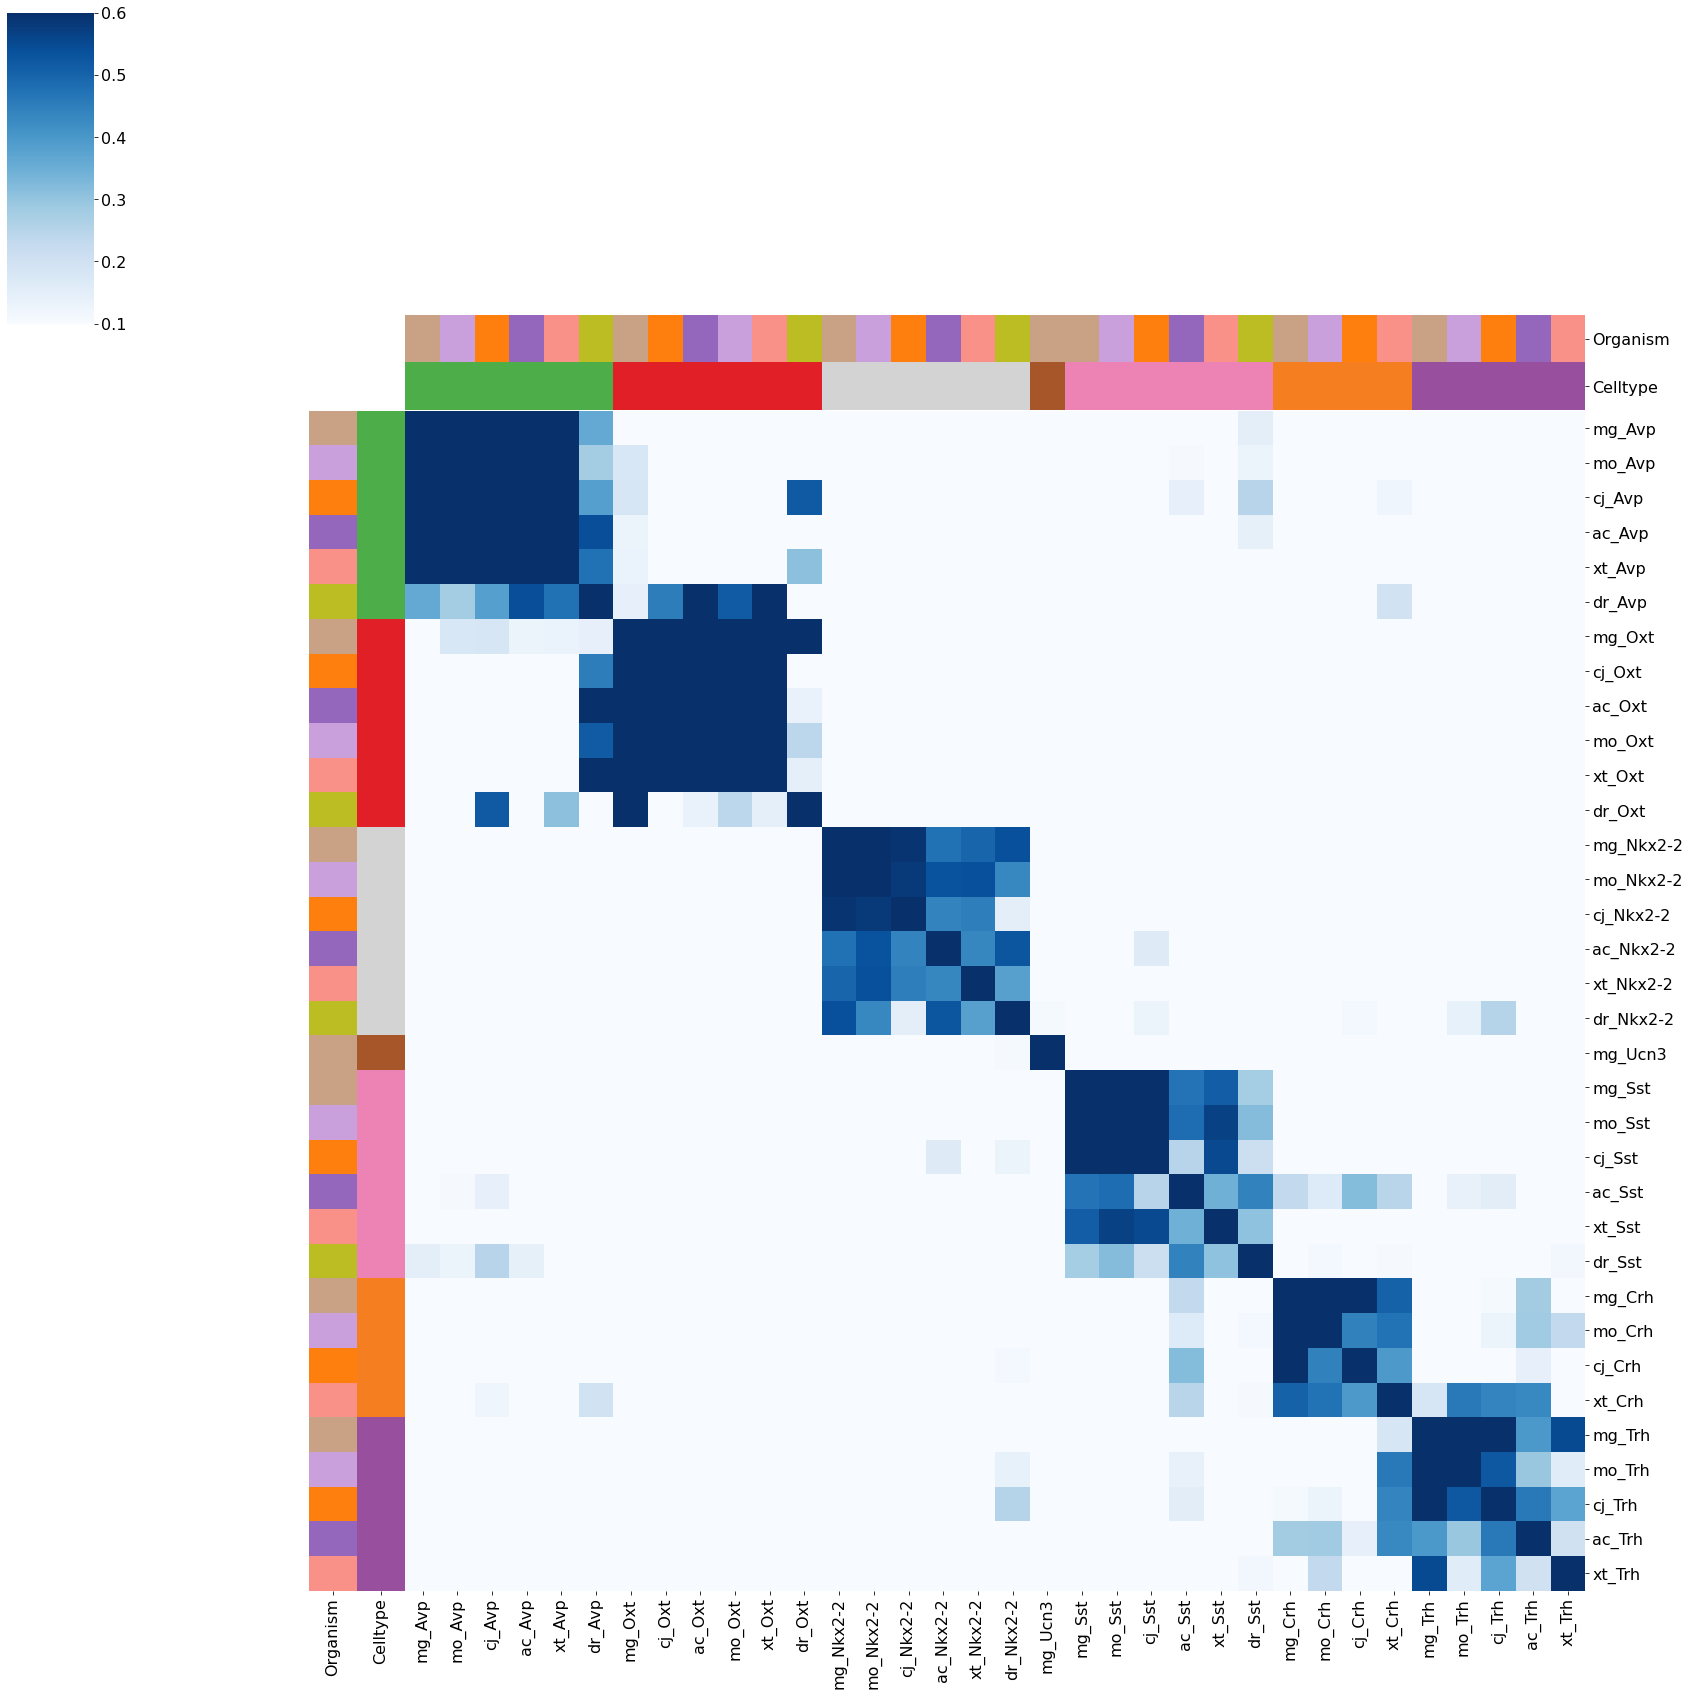

In [17]:
plt.rcParams['font.size'] = 16
g =sns.clustermap(pvh_mapping_ord, vmax = .6,vmin=0.1, cmap = 'Blues',figsize=(24,24),col_colors = col_colors, row_colors = col_colors,row_cluster = False, col_cluster = False)
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
plt.savefig('../../Figures/Figures_07242026/Hypoorgs_PVH_heatmap_07262026.svg')
plt.savefig('../../Figures/Figures_07242026/Hypoorgs_PVH_heatmap_07262026.png', dpi = 600)
plt.savefig('../../Figures/Figures_07242026/Hypoorgs_PVH_heatmap_07262026.pdf')